In [1]:
import os

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from omegaconf import OmegaConf
from matplotlib.colors import TwoSlopeNorm
from sunpy.visualization.colormaps import color_tables

from sdofmv2.core import MAE, SDOMLDataModule, inverse_log_norm, mapping_dense_to_rgb, plot_heads, patch_attn_layers, visualize_head
from sdofmv2.utils import ALL_COMPONENTS


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = OmegaConf.load(
    "../../configs/pretrain/pretrain_mae_HMI.yaml"
    )

In [3]:
data_module = SDOMLDataModule(
    hmi_path=os.path.join(
        cfg.data.sdoml.base_directory, 
        cfg.data.sdoml.sub_directory.hmi
    ) if cfg.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg.data.sdoml.base_directory,
        cfg.data.sdoml.sub_directory.aia,
    ) if cfg.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg.data.sdoml.components,
    wavelengths=cfg.data.sdoml.wavelengths,
    ions=cfg.data.sdoml.ions,
    frequency=cfg.data.sdoml.frequency,
    batch_size=cfg.model.misc.batch_size,
    num_workers=cfg.data.num_workers,
    val_months=cfg.data.month_splits.val,
    test_months=cfg.data.month_splits.test,
    holdout_months=cfg.data.month_splits.holdout,
    cache_dir=os.path.join(
        "../../assets",
        cfg.data.sdoml.sub_directory.cache,
    ),
    min_date=cfg.data.min_date,
    max_date=cfg.data.max_date,
    num_frames=cfg.model.mae.num_frames,
    drop_frame_dim=cfg.data.drop_frame_dim,
    apply_mask=cfg.data.sdoml.apply_mask,
    precision=cfg.experiment.precision,
    normalization=cfg.data.sdoml.normalization,
)
data_module.setup()

[* CACHE SYSTEM *] Found cached index data in ../../assets/cache/aligndata_HMI_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-09 01:57:40.691 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/HMI/Bx_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:57:40.692 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/HMI/By_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:57:40.693 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../assets/cache/HMI/Bz_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-09 01:57:40.731 | INFO     | sdofmv2.core.datamodule:setup:1070 - Train dataloader is ready!
2026-03-09 01:57:40.732 | INFO     | sdofmv2.core.datamodule:setup:1071 - Dataset size: 284813
2026-03-09 01:57:40.750 | INFO     | sdofmv2.core.datamodule:setup:1093 - Validation dataloader is ready!
2026-03-09 01:57:40.751 | INFO     | sdofmv2.core.datamodule:setup:1094 - Dataset size: 30533
2026-03-09 01:57:40.764 | INFO     | sdofmv2.c

[* CACHE SYSTEM *] Found cached HMI mask data in ../../assets/cache/hmi_mask_512x512.npy.


In [4]:
ckpt_dir = "../../assets/check_point/backbone/"
model = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "HMI/id_mycczy8p_mae_epoch=299-val_loss=0.03.ckpt", 
    map_location="cpu",
    weights_only=False)
model.eval()

model_loss_inner_only = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "HMI/id_do2piiw5_mae_epoch=96-val_loss=0.00.ckpt", 
    map_location="cpu",
    weights_only=False)
model_loss_inner_only.eval()

MAE(
  (autoencoder): MaskedAutoencoderViT3D(
    (patch_embed): PatchEmbed(
      (proj): Conv3d(3, 768, kernel_size=(1, 16, 16), stride=(1, 16, 16))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (drop1): Dropout(p=0.0, inplace=False)
       

In [5]:
timestamps = [
    "2011-12-25 00:12:00",
    "2012-12-25 00:12:00",
    "2013-12-25 00:12:00",
    "2014-12-25 00:12:00",
    "2015-12-25 00:12:00"
    ]

img_indices = [
    data_module.test_ds.aligndata.index.get_loc(
        pd.to_datetime(i_time)
    ) for i_time in timestamps
]

x_set = torch.cat([data_module.test_ds[i][0].unsqueeze(0) for i in img_indices], dim=0)
ts = [pd.to_datetime(data_module.test_ds[i][1]) for i in img_indices]

print(f"Datetime: {ts}")

Datetime: [Timestamp('2011-12-25 00:12:00'), Timestamp('2012-12-25 00:12:00'), Timestamp('2013-12-25 00:12:00'), Timestamp('2014-12-25 00:12:00'), Timestamp('2015-12-25 00:12:00')]


In [6]:
components = ALL_COMPONENTS
components.sort()
x_set_norm = x_set.clone()
# norm information
norm_stat = {"HMI": {}}
for ch_id, ch in enumerate(components):
    
    cache_path = "../../assets/cache/HMI/"
    file_name = (
        ch
        + "_"
        + "_".join(data_module.cache_id.split("_")[-1:])
        + f"_norm-{data_module.normalization.type}"
        + ".json"
    )

    with open(cache_path + file_name, "r") as json_file:
        ch_stat = json.load(json_file)
    
    norm_stat["HMI"][ch] = ch_stat

# input/output inverse log transform for visualization
for i_img in range(x_set.shape[0]):
    for ch_id, ch in enumerate(components):

        x_set_norm[i_img, ch_id, 0, :, :] = inverse_log_norm(
            x_set[i_img, ch_id, 0, :, :],
            norm_stat,
            "HMI",
            ch,
            cfg.data.sdoml.normalization.scaler_factor,
            cfg.data.sdoml.normalization.scaler_div_factor
        )

In [7]:
pca_results = []
pca_results_loss_inner_only = []

for img_id in range(x_set.shape[0]):
    with torch.no_grad():
        latent, mask, ids_restore = model.autoencoder.forward_encoder(x_set_norm[[img_id]], mask_ratio=0)
        latent_inner, _, ids_restore_inner = model_loss_inner_only.autoencoder.forward_encoder(x_set_norm[[img_id]], mask_ratio=0)
    
    latent_size = latent.shape[1] - 1
    ids_keep = torch.argsort(ids_restore.squeeze())[:latent_size]
    ids_keep_inner = torch.argsort(ids_restore_inner.squeeze())[:latent_size]
    feature_maps = latent[0, 1:, :]
    feature_maps_inner = latent_inner[0, 1:, :]

    rgb_img = mapping_dense_to_rgb(
        feature_map=feature_maps, 
        visible_patch_ids=ids_keep,
        n_components=3,
        img_size=cfg.model.mae.img_size,
        grid_size=(cfg.model.mae.img_size // cfg.model.mae.patch_size),
        patch_size=cfg.model.mae.patch_size,
        pretrained=None
    )

    rgb_img_inner = mapping_dense_to_rgb(
        feature_map=feature_maps_inner, 
        visible_patch_ids=ids_keep_inner,
        n_components=3,
        img_size=cfg.model.mae.img_size,
        grid_size=(cfg.model.mae.img_size // cfg.model.mae.patch_size),
        patch_size=cfg.model.mae.patch_size,
        pretrained=None
    )

    pca_results.append(rgb_img)
    pca_results_loss_inner_only.append(rgb_img_inner)

In [8]:
# num_images = x.shape[0]
# fig, axs = plt.subplots(num_images, 4, figsize=(25, 4), squeeze=False)

# hmi_cmap= color_tables.hmi_mag_color_table()
# norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)
# for i in range(num_images):
#     for i_ch, ch in enumerate(["Bx", "By", "Bz"]):
#         axs[i, i_ch].imshow(x[i, i_ch, 0, :, :], cmap=hmi_cmap, norm=norm)
#         axs[i, i_ch].set_title(f"{ch}")
#         axs[i, i_ch].axis('off')

#     axs[i, 3].imshow(rgb_img)
#     axs[i, 3].set_title(f"PCA")
#     axs[i, 3].axis('off')

# plt.tight_layout()
# plt.savefig("pca_analysis_HMI.pdf", dpi=300, bbox_inches="tight")
# # plt.show()

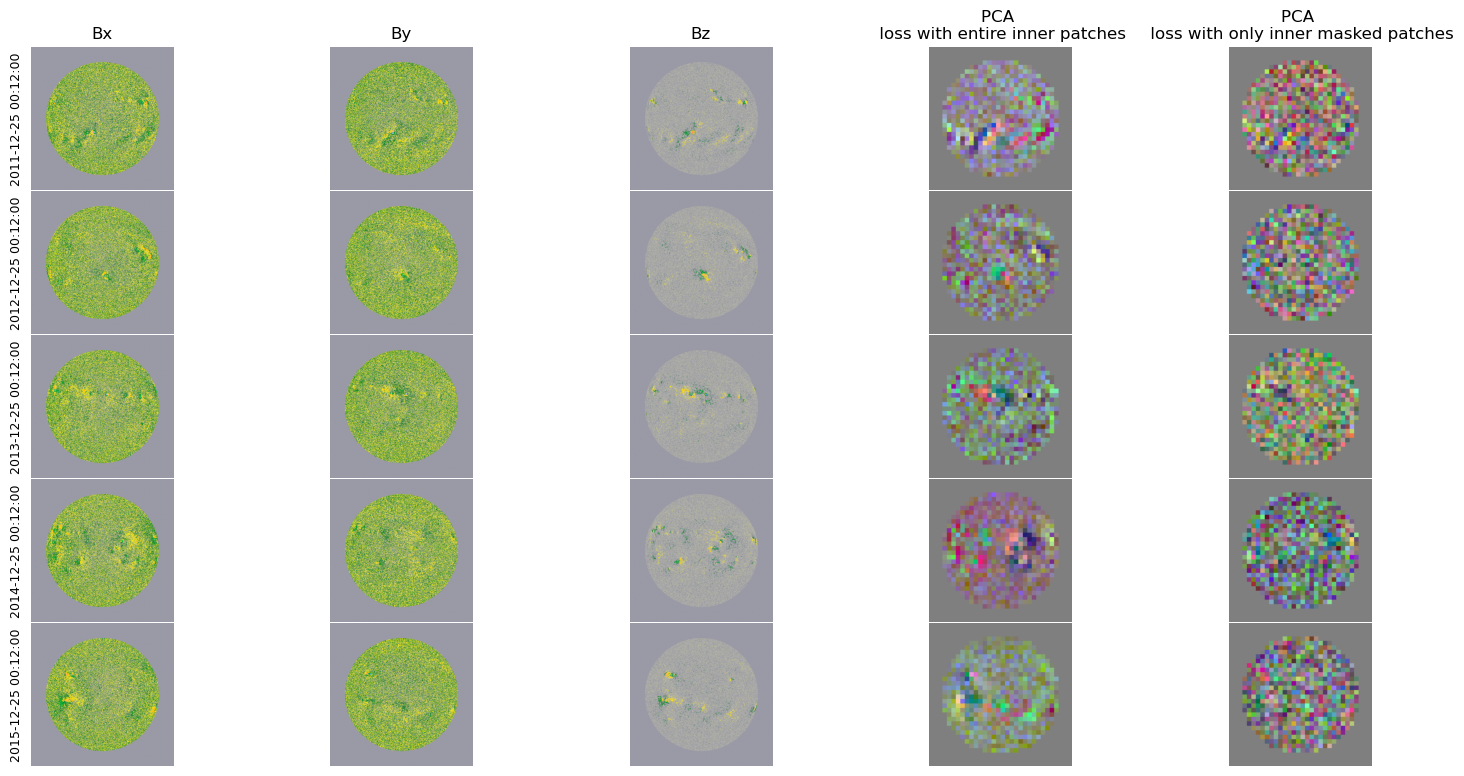

In [9]:
hmi_cmap= color_tables.hmi_mag_color_table()
norm = TwoSlopeNorm(vmin=-4000, vcenter=0, vmax=4000)

num_images = x_set.shape[0]
fig, axes = plt.subplots(num_images, 5, figsize=(15, 8), squeeze=False)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

ch_info = ["Bx", "By", "Bz"]

for i in range(num_images):
    for i_col, col in enumerate(ch_info):
        if i == 0:
            axes[i, i_col].set_title(f"{col}", fontsize=12)
            axes[i, 3].set_title(f"PCA \n loss with entire inner patches", fontsize=12)
            axes[i, 4].set_title(f"PCA \n loss with only inner masked patches", fontsize=12)


        axes[i, i_col].imshow(
            x_set_norm[i, i_col, 0, :, :].to("cpu").numpy(), 
            cmap=hmi_cmap, 
            norm=norm
            )
        axes[i, i_col].axis('off')

    axes[i, 3].imshow(pca_results[i])
    axes[i, 3].axis('off')

    axes[i, 4].imshow(pca_results_loss_inner_only[i])
    axes[i, 4].axis('off')

for row_idx in range(num_images):
    axes[row_idx][0].text(
        -0.1, 0.5,              # Negative x moves it to the left
        f"{ts[row_idx]}", 
        ha='center', 
        va='center', 
        fontsize=9, 
        rotation=90,
        transform=axes[row_idx][0].transAxes # Ensures coordinates are relative to the subplot
    )

plt.tight_layout()

# wspace=0.1 means the gap is 10% of the subplot width
# hspace=0.1 means the gap is 10% of the subplot height
plt.subplots_adjust(wspace=0.1, hspace=0.01) 
plt.savefig("pca_analysis_HMI.pdf", dpi=300, bbox_inches="tight")

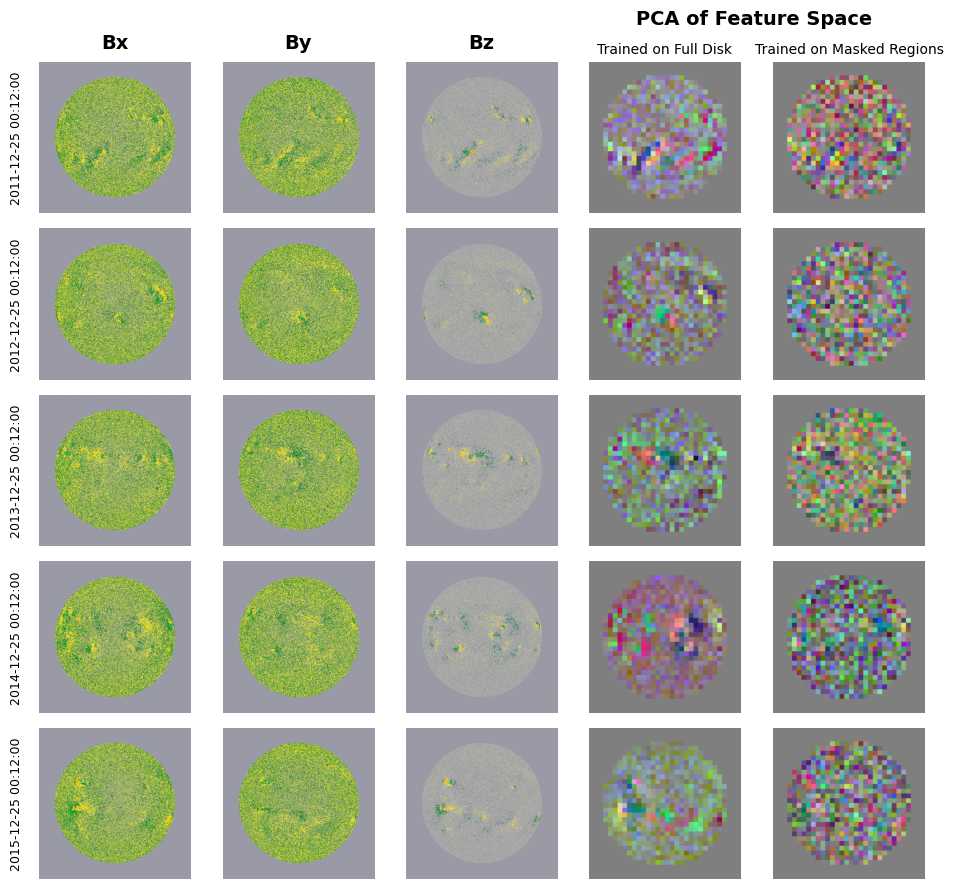

In [ ]:
# Increase top margin in figsize to make room for spanning title
fig, axes = plt.subplots(num_images, 5, figsize=(10, 9.5), squeeze=False)

for ax in axes.flat:
    ax.set_axis_off()

ch_info = ["Bx", "By", "Bz"]

for i in range(num_images):
    for i_col, col in enumerate(ch_info):
        if i == 0:
            axes[i, i_col].set_title(f"{col}", fontsize=14, fontweight='bold', pad=10)
            
        axes[i, i_col].imshow(x_set_norm[i, i_col, 0, :, :], cmap=hmi_cmap, norm=norm)

    axes[i, 3].imshow(pca_results[i])
    axes[i, 4].imshow(pca_results_loss_inner_only[i])

for row_idx in range(num_images):
    axes[row_idx][0].text(-0.15, 0.5, f"{ts[row_idx]}", ha='center', va='center', fontsize=9, rotation=90, transform=axes[row_idx][0].transAxes)


# Get the positions of the 4th and 5th axes on the top row
pos3 = axes[0, 3].get_position()
pos4 = axes[0, 4].get_position()

# Calculate the center x-coordinate between these two axes
span_center_x = (pos3.x0 + pos4.x1) / 2
# Calculate a y-coordinate slightly above them
span_top_y = pos3.y1 + 0.04

# Add the main spanning title
fig.text(span_center_x + 0.05, span_top_y, "PCA of Feature Space", 
         ha='center', fontsize=14, fontweight='bold')

# Add sub-titles for context below the main span title
fig.text(pos3.x0 + pos3.width/2 + 0.04, pos3.y1 + 0.01, "Trained on Full Disk", ha='center', fontsize=10)
fig.text(pos4.x0 + pos4.width/2 + 0.065, pos4.y1 + 0.01, "Trained on Masked Regions", ha='center', fontsize=10)


# Adjust layout to make room at the top
plt.subplots_adjust(wspace=0.1, hspace=0.1, top=0.88, left=0.08, right=0.98, bottom=0.02)
plt.savefig("pca_analysis_HMI.pdf", dpi=300, bbox_inches="tight")